<h3> MLP: </h3>
Input -> Layer_0 -> Layer_1 -> Layer_2(Output) <br>
Input = Observation Space (Time, Joint Pos/Vel, ...) <br>
Output = Action Space (Muscle Actuator intensities for 63 muscles) <br>

In [1]:
import myosuite
import gym
import skvideo.io
import numpy as np
import os
import imageio
import tqdm
import time

MyoSuite:> Registering Myo Envs


In [2]:
from IPython.display import HTML
from base64 import b64encode

def show_video(video_path, video_width = 400):

  video_file = open(video_path, "r+b").read()

  video_url = f"data:video/mp4;base64,{b64encode(video_file).decode()}"
  return HTML(f"""<video autoplay width={video_width} controls><source src="{video_url}"></video>""")


Get Policy

In [3]:
policy = "./policies/seed_42/best_policy.pickle" #Change the folder to the policy location

import pickle
# load policy
pi = pickle.load(open(policy, 'rb'))

Get Object Coordinates

In [26]:

env = gym.make('CenterReachOut-v0')
coordinates_2d = []
for x in env.obj_xyz_range:
    coordinates_2d.append(x[:2])
    
print(coordinates_2d)


[[-0.03125069216102037, -0.024064832105254508], [0.10199416560603433, -0.3457434044594767], [0.15718516789601672, -0.2125], [0.1019938068049917, -0.07925623673839724], [-0.031249807868617828, -0.40093516789591876], [-0.16449389389172694, -0.3457436761747822], [-0.21968516789535328, -0.21249949997036174], [-0.1680450158763584, -0.07925561667782058]]


<h1> Turn into Polar Coordinates </h1>

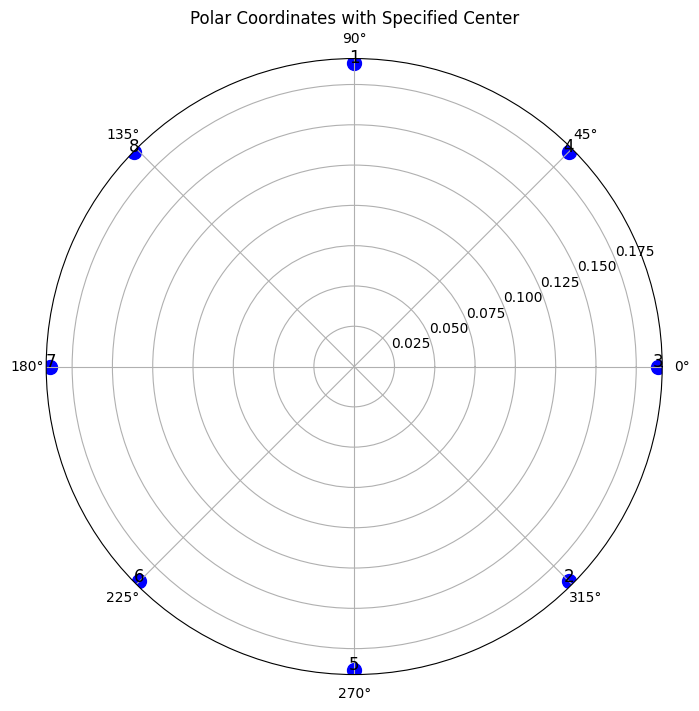

Point 1: r = 0.188, θ = 1.57 rad, xy: [-0.03125069216102037, -0.024064832105254508]
Point 2: r = 0.188, θ = 5.50 rad, xy: [0.10199416560603433, -0.3457434044594767]
Point 3: r = 0.188, θ = 0.00 rad, xy: [0.15718516789601672, -0.2125]
Point 4: r = 0.188, θ = 0.79 rad, xy: [0.1019938068049917, -0.07925623673839724]
Point 5: r = 0.188, θ = 4.71 rad, xy: [-0.031249807868617828, -0.40093516789591876]
Point 6: r = 0.188, θ = 3.93 rad, xy: [-0.16449389389172694, -0.3457436761747822]
Point 7: r = 0.188, θ = 3.14 rad, xy: [-0.21968516789535328, -0.21249949997036174]
Point 8: r = 0.191, θ = 2.37 rad, xy: [-0.1680450158763584, -0.07925561667782058]
{(-0.03125069216102037, -0.024064832105254508): 1.5708, (0.10199416560603433, -0.3457434044594767): 5.49779, (0.15718516789601672, -0.2125): 0.0, (0.1019938068049917, -0.07925623673839724): 0.785398, (-0.031249807868617828, -0.40093516789591876): 4.71239, (-0.16449389389172694, -0.3457436761747822): 3.92699, (-0.21968516789535328, -0.21249949997036174)

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Given 2D Cartesian coordinates (x, y) and the center (xc, yc)
cartesian_coords_2d = coordinates_2d  # Example coordinates, replace with your actual data
center = (-0.03125, -0.21250)

# Conversion function for 2D Cartesian to Polar with a specified center
def cartesian_to_polar_center(coords, center):
    x, y = coords
    xc, yc = center
    x_prime = x - xc
    y_prime = y - yc
    r = np.sqrt(x_prime**2 + y_prime**2)
    theta = np.arctan2(y_prime, x_prime)
    if theta < 0:
        theta += 2 * np.pi  # Ensure the angle is within [0, 2π]
    return r, theta

# Convert all 2D coordinates
polar_coords_2d_centered = [cartesian_to_polar_center(coord, center) for coord in cartesian_coords_2d]

# Extract r and theta values
r_values = [coord[0] for coord in polar_coords_2d_centered]
theta_values = [coord[1] for coord in polar_coords_2d_centered]  # Already in radians and positive

# Create polar plot
plt.figure(figsize=(8, 8))
ax = plt.subplot(111, projection='polar')
ax.scatter(theta_values, r_values, c='blue', s=100)  # Plot the points

# Add labels for clarity
for i, (r, theta) in enumerate(zip(r_values, theta_values)):
    ax.text(theta, r, f'{i+1}', fontsize=12, ha='center')

ax.set_title("Polar Coordinates with Specified Center")
plt.show()

coords_to_angles = {}

# Print the results
for i, (r, theta) in enumerate(polar_coords_2d_centered):
    coords_to_angles[tuple(cartesian_coords_2d[i])] = theta
    print(f"Point {i+1}: r = {r:.3f}, θ = {theta:.2f} rad, xy: {cartesian_coords_2d[i]}")

print(coords_to_angles)


coords_to_angles dictionary now contains the coordinates with their assigned angle

<h1> Setting up the data collection </h1>
<p> We will create a dictionary that contains: <br>
    - Keys = Action Number (int) <br>
    - Values = Angle (float) - Neuron Activations (list) <br>
    </p>

In [ ]:
# Use sleep if you want to examine certain steps during the episodes
from time import sleep

Cosine_Tuning_Data = {} 
neural_num = 64

print(coords_to_angles)

frames = []
for ep_num in range(8): 
  env.reset()
  ep_rewards = []
  done = False
  obs = env.reset()
  for ac_num in range(16):
      frame = env.sim.renderer.render_offscreen(
                        width=400,
                        height=400,
                        camera_id=1)
      frames.append(frame)
      print(env.obs_dict['time'])
      o = env.get_obs()
      action, _ = pi.get_action(o)
      obs, reward, done, info = env.step(action)
      
      #If you want to see the neuron activations

      #Register the data for every action in each episode
      #cosine_Tuning_Data[ep_num*10 + ac_num] = [coords_to_angles[tuple(env.current_object_pos[:2])], pi.show_activations()['layer_0'][0][3], pi.show_activations()['layer_0'][0][20], pi.show_activations()['layer_0'][0][33] ]
      
      #Register the data for episode
      Cosine_Tuning_Data[ep_num] = [coords_to_angles[tuple(env.current_object_pos[:2])]]
      
      activations = {}
      
      #Registering Layer 1 
      for n in range(neural_num):
          Cosine_Tuning_Data[ep_num].append(pi.show_activations()['layer_0'][0][n])
      
      #Registering Layer 2
      for m in range(neural_num):
        Cosine_Tuning_Data[ep_num].append(pi.show_activations()['layer_1'][0][m])
      


env.close()

os.makedirs('videos', exist_ok=True)
video_path = 'videos/test_policy.mp4'
# make a local copy
imageio.mimsave(video_path, frames, fps=30)
show_video('videos/test_policy.mp4')

{(-0.03125069216102037, -0.024064832105254508): 1.5708, (0.10199416560603433, -0.3457434044594767): 5.49779, (0.15718516789601672, -0.2125): 0.0, (0.1019938068049917, -0.07925623673839724): 0.785398, (-0.031249807868617828, -0.40093516789591876): 4.71239, (-0.16449389389172694, -0.3457436761747822): 3.92699, (-0.21968516789535328, -0.21249949997036174): 3.14159, (-0.1680450158763584, -0.07925561667782058): 2.3693423048036895}
[0.]


AttributeError: 'numpy.ndarray' object has no attribute 'append'

<h1> Create a Table with Data </h1>

In [27]:
import pandas as pd

data = Cosine_Tuning_Data

# Create a DataFrame
df = pd.DataFrame.from_dict(data, orient='index')
print(df)
# Convert DataFrame to HTML table
html_table = df.to_html()


# Write HTML table to a file
with open('table.html', 'w') as f:
    f.write(html_table)

      0         1         2         3         4         5         6    \
0  0.0000  0.022572  0.293287  0.298264  0.323549  0.283344  0.006236   
1  1.5708  0.030086  0.458169  0.326989  0.258496  0.172554  0.013740   

        7         8         9    ...       503       504       505       506  \
0  0.030994  0.155738  0.385745  ...  0.999703  0.004973  0.978357  0.081951   
1  0.069943  0.098154  0.361363  ...  0.999485  0.003242  0.992109  0.122407   

        507       508       509       510       511       512  
0  0.928307  0.502936  0.999847  0.007418  0.928768  0.470201  
1  0.961603  0.262459  0.999888  0.008296  0.932387  0.349315  

[2 rows x 513 columns]


<h3> Cosine Tuning:  </h3> 
    - Define Directions in Radians <br> <br>
    - Compute Cosine Tuning for a neuron using the appropriate function: <br>  f(s) = r0 + (rmax - r0)* cos(s - smax) <br> <br>
    <b> rmax: </b> highest firing rate <br> <br>
    <b> r0: </b> firing rate when movement degree is null <br> <br>
    <b> smax: </b> direction angle at which firing rate is maximal  <br> <br>
  

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Create a DataFrame
df = pd.DataFrame.from_dict(data, orient='index', columns=['Angle'] + [f'Neuron Activation {i+1}' for i in range(512)])

# Convert the angle from radians to degrees
df['Angle'] = np.degrees(df['Angle'])

# Group by angle and get the maximum value for each neuron activation
average_values = df.groupby('Angle').max()

# Reset the index to ensure 'Angle' is a column again
average_values.reset_index(inplace=True)
# Print the processed data
print(average_values)

      Angle  Neuron Activation 1  Neuron Activation 2  Neuron Activation 3  \
0   0.00000             0.022572             0.293287             0.298264   
1  90.00021             0.030086             0.458169             0.326989   

   Neuron Activation 4  Neuron Activation 5  Neuron Activation 6  \
0             0.323549             0.283344             0.006236   
1             0.258496             0.172554             0.013740   

   Neuron Activation 7  Neuron Activation 8  Neuron Activation 9  ...  \
0             0.030994             0.155738             0.385745  ...   
1             0.069943             0.098154             0.361363  ...   

   Neuron Activation 503  Neuron Activation 504  Neuron Activation 505  \
0               0.999703               0.004973               0.978357   
1               0.999485               0.003242               0.992109   

   Neuron Activation 506  Neuron Activation 507  Neuron Activation 508  \
0               0.081951               0.92

FileNotFoundError: [Errno 2] No such file or directory: 'figures/Neuron_Activation_1.png'

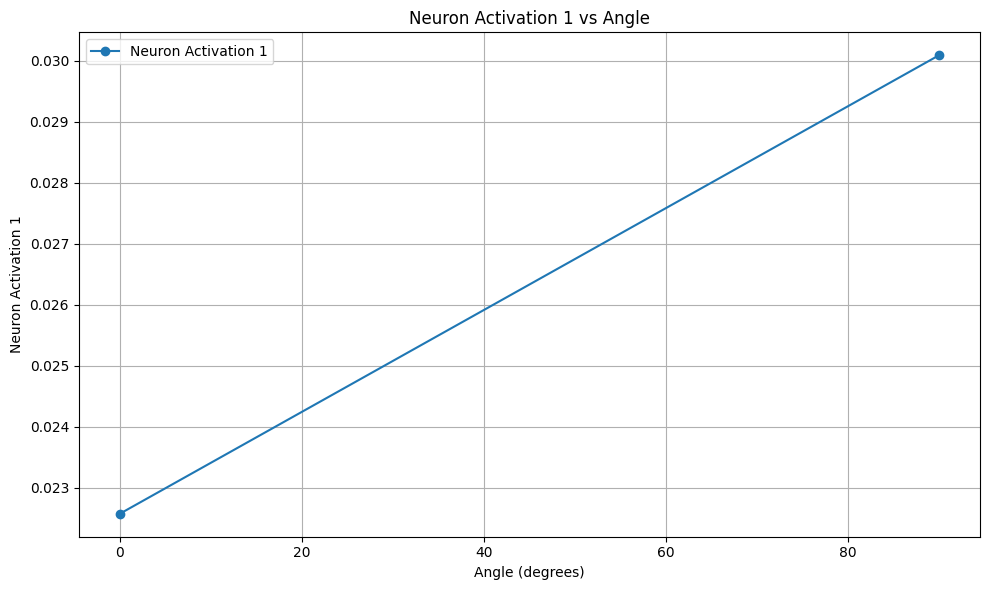

In [29]:

# Generate plots for each neuron activation
for i in range(1, 513):
    plt.figure(figsize=(10, 6))
    plt.plot(average_values['Angle'], average_values[f'Neuron Activation {i}'], marker='o', label=f'Neuron Activation {i}')
    plt.xlabel('Angle (degrees)')
    plt.ylabel(f'Neuron Activation {i}')
    plt.title(f'Neuron Activation {i} vs Angle')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'figures/Neuron_Activation_{i}.png')
    plt.close()
print(df)
# Convert DataFrame to HTML table
html_table = df.to_html()

# Write HTML table to a file
with open('table.html', 'w') as f:
    f.write(html_table)

<h3> Create the Polar Historgram </h3>
<p> We Want to get the tuned angle for each neuron and create a polar histogram based on that </p>

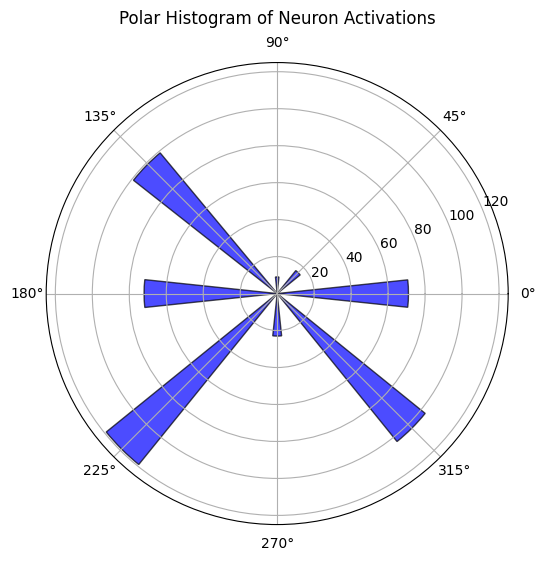

In [ ]:
# Finding the angles with maximum activations for each neuron
max_angles = {}
for column in df.columns[1:]:  # Skip the 'Angle' column
    max_index = df[column].idxmax()  # Index of the maximum activation
    max_angles[column] = df.loc[max_index, 'Angle']  # Corresponding angle

# Extracting the list of angles from max_angles
angles_list = list(max_angles.values())

# Counting the frequency of each unique angle
angle_counts = pd.Series(angles_list).value_counts().sort_index()

# Extracting unique angles and their counts
unique_angles = angle_counts.index.tolist()
counts = angle_counts.values

# Converting angles to radians for the polar histogram
angles_rad = np.deg2rad(unique_angles)

# Create polar histogram
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, polar=True)
bars = ax.bar(angles_rad, counts, width=np.pi/15, color='blue', alpha=0.7, edgecolor='black')

# Setting the title and labels
ax.set_title('Polar Histogram of Neuron Activations', va='bottom')

# Showing the plot
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Assuming 'data' is a dictionary with your data
# Create a DataFrame
df = pd.DataFrame.from_dict(data, orient='index', columns=['Angle'] + [f'Neuron Activation {i+1}' for i in range(512)])

# Convert the angle from radians to degrees
df['Angle'] = np.degrees(df['Angle'])

# Group by angle and get the maximum value for each neuron activation
average_values = df.groupby('Angle').max()

# Reset the index to ensure 'Angle' is a column again
average_values.reset_index(inplace=True)

# Print the processed data
print(average_values)

# Polynomial degree
degree = 3

# Initialize a list to store the MSEs
mse_results = []

# Generate plots for each neuron activation
for i in range(1, 513):
    X = average_values[['Angle']]
    y = average_values[f'Neuron Activation {i}']

    # Transform the features to polynomial features
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X)

    # Fit the polynomial regression model
    poly_reg_model = LinearRegression()
    poly_reg_model.fit(X_poly, y)

    # Generate predictions
    y_poly_pred = poly_reg_model.predict(X_poly)

    # Create a cosine function for comparison
    angle_radians = np.radians(average_values['Angle'])
    y_cosine = np.cos(angle_radians)

    # Normalize cosine function to match the scale of neuron activations
    y_cosine_normalized = (y_cosine - y_cosine.min()) / (y_cosine.max() - y_cosine.min())
    y_cosine_normalized = y_cosine_normalized * (y.max() - y.min()) + y.min()

    # Calculate MSE between polynomial fit and cosine function
    mse = mean_squared_error(y_poly_pred, y_cosine_normalized)
    mse_results.append(mse)

    # Plot the data, polynomial regression curve, and cosine function
    plt.figure(figsize=(10, 6))
    plt.scatter(average_values['Angle'], y, color='blue', marker='o', label='Original Data')
    plt.plot(average_values['Angle'], y_poly_pred, color='red', label=f'Polynomial Fit (degree {degree})')
    plt.plot(average_values['Angle'], y_cosine_normalized, color='green', linestyle='--', label='Cosine Function')
    plt.xlabel('Angle (degrees)')
    plt.ylabel(f'Neuron Activation {i}')
    plt.title(f'Neuron Activation {i} vs Angle')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'figures/Neuron_Activation_{i}_polyfit_cosine.png')
    plt.close()

# Print the MSE results
for i, mse in enumerate(mse_results, 1):
    print(f'MSE for Neuron Activation {i}: {mse}')

# Convert DataFrame to HTML table
html_table = df.to_html()

# Write HTML table to a file
with open('table.html', 'w') as f:
    f.write(html_table)


        Angle  Neuron Activation 1  Neuron Activation 2  Neuron Activation 3  \
0    0.000000             0.041481             0.630586             0.308224   
1   44.999991             0.045177             0.755290             0.423341   
2   90.000210             0.066995             0.745094             0.522859   
3  135.753314             0.101484             0.772908             0.519356   
4  179.999848             0.109442             0.804856             0.274020   
5  224.999953             0.109437             0.744770             0.235590   
6  270.000058             0.043469             0.581166             0.296315   
7  315.000164             0.036341             0.557838             0.279959   

   Neuron Activation 4  Neuron Activation 5  Neuron Activation 6  \
0             0.337035             0.561150             0.284809   
1             0.379505             0.454421             0.472072   
2             0.359579             0.227055             0.428111   
3      

<h3> Cosine fitting and calculating error </h3>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error

# Assuming 'data' is a dictionary with your data
# Create a DataFrame
df = pd.DataFrame.from_dict(data, orient='index', columns=['Angle'] + [f'Neuron Activation {i+1}' for i in range(512)])

# Convert the angle from radians to degrees
df['Angle'] = np.degrees(df['Angle'])

# Group by angle and get the maximum value for each neuron activation
average_values = df.groupby('Angle').max()

# Reset the index to ensure 'Angle' is a column again
average_values.reset_index(inplace=True)

# Function to define a cosine function
def cosine_func(x, amplitude, phase_shift, vertical_shift):
    return amplitude * np.cos(np.radians(x) + phase_shift) + vertical_shift

# Polynomial degree
degree = 3

# Store MSE values for each neuron
mse_values = {'Neuron': [], 'Poly-Cosine MSE': []}

# Generate plots for each neuron activation
for i in range(1, 513):
    X = average_values[['Angle']]
    y = average_values[f'Neuron Activation {i}']

    # Transform the features to polynomial features
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X)

    # Fit the polynomial regression model
    poly_reg_model = LinearRegression()
    poly_reg_model.fit(X_poly, y)

    # Generate predictions
    y_poly_pred = poly_reg_model.predict(X_poly)

    # Fit a cosine function to the data
    initial_guess = [np.ptp(y) / 2, 0, np.mean(y)]  # Amplitude, phase shift, vertical shift
    params, params_covariance = curve_fit(cosine_func, average_values['Angle'], y, p0=initial_guess)

    # Generate cosine predictions
    y_cosine_pred = cosine_func(average_values['Angle'], *params)

    # Calculate MSE for both polynomial and cosine fits
    mse_poly = mean_squared_error(y, y_poly_pred)
    mse_cosine = mean_squared_error(y, y_cosine_pred)

    # Calculate MSE between polynomial and cosine fits
    mse_poly_cosine = mean_squared_error(y_poly_pred, y_cosine_pred)

    # Store MSE values
    mse_values['Neuron'].append(f'Neuron Activation {i}')
    mse_values['Poly-Cosine MSE'].append(mse_poly_cosine)

    # Generate a fine grid of angles for smooth plotting
    fine_angles = np.linspace(average_values['Angle'].min(), average_values['Angle'].max(), 1000)
    y_cosine_best_fit = cosine_func(fine_angles, *params)

    # Plot the data, polynomial regression curve, and best fit cosine function
    plt.figure(figsize=(10, 6))
    plt.scatter(average_values['Angle'], y, color='blue', marker='o', label='Original Data')
    plt.plot(average_values['Angle'], y_poly_pred, color='red', label=f'Polynomial Fit (degree {degree})')
    plt.plot(fine_angles, y_cosine_best_fit, color='green', linestyle='--', label='Best Fit Cosine Function')
    plt.xlabel('Angle (degrees)')
    plt.ylabel(f'Neuron Activation {i}')
    plt.title(f'Neuron Activation {i} vs Angle')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'figures/Neuron_Activation_{i}_polyfit_cosine.png')
    plt.close()

# Convert MSE values to a DataFrame
mse_df = pd.DataFrame(mse_values)

# Save the MSE values to an HTML file
html_content = mse_df.to_html(index=False)

with open('mse_values.html', 'w') as f:
    f.write(html_content)

print('MSE values saved to mse_values.html')


MSE values saved to mse_values.html
